In [1]:
# suppress tensorflow logging, usually not useful unless you are having problems with tensorflow or accessing gpu
# it seems necessary to have this environment variable set before tensorflow is imported, or else it doesn't take effect
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.special import softmax
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import TextVectorization

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

In [2]:
# import project defined modules / functions used in this notebook
# ensure that the src directory where project modules are found is on
# the PYTHONPATH
import sys
sys.path.append("../src")

# assignment function imports for doctests and github autograding
# these are required for assignment autograding
from nndl import vectorize_samples, plot_history

In [3]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
dev = tf.config.list_physical_devices()
print('Physical Devices : ', dev)

#tf.config.set_visible_devices(dev[0])
#tf.config.set_visible_devices(dev[1])
dev = tf.config.list_logical_devices()
print('Available Devices : ', dev)

Physical Devices :  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Available Devices :  [LogicalDevice(name='/device:CPU:0', device_type='CPU'), LogicalDevice(name='/device:GPU:0', device_type='GPU')]


I0000 00:00:1750787054.919706   27003 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


# Chapter 12: Generative Deep Learning

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

Generative AI and using deep learning architectures is particulary popular right now,
though I personally agree with the assessment that it "has fed a (not so) short-lived hype
wave worthy of the most torrid AI summer.  In any case, the promise of generative AI is that
it can be used as a tool to augment human capabilities, so more generative augmentive intelligence
rather than artifical general intelligence.

In this section we will look at some of the basic mechanisms and architectures for building generative
systems using deep learning networks.  We will look at generating text and images, and
what autoencoders and GAN networks are all about.

## 12.3 Neural Style Transfer

### 12.3.1 The Content Loss

### 12.3.2 The Style Loss

### 12.3.3 Neural Style Transfer in Keras

Neural style transfer can be implemented using any pretrained convnet. Here, we’ll
use the VGG19 network. 

Here’s the general process:

- Set up a network that computes VGG19 layer activations for the style-reference
  image, the base image, and the generated image at the same time.
- Use the layer activations computed over these three images to define the loss
  function described earlier, which we’ll minimize in order to achieve style
  transfer.
- Set up a gradient-descent process to minimize this loss function.

Let’s start by defining the paths to the style-reference image and the base image.

In [4]:
# getting the style and content images
base_image_path = keras.utils.get_file("sf.jpg", origin="https://img-datasets.s3.amazonaws.com/sf.jpg")
style_reference_image_path = keras.utils.get_file("starry_night.jpg", origin="https://img-datasets.s3.amazonaws.com/starry_night.jpg")

# dimensions of original and generated pictures
original_width, original_height = keras.utils.load_img(base_image_path).size
img_height = 400
img_width = round(original_width * img_height / original_height)

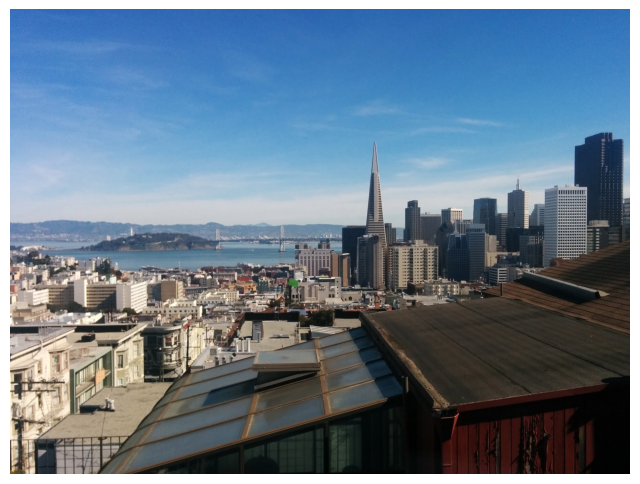

In [5]:
# the content image, San Francisco from Nob Hill
plt.axis("off")
plt.imshow(keras.utils.load_img(base_image_path));

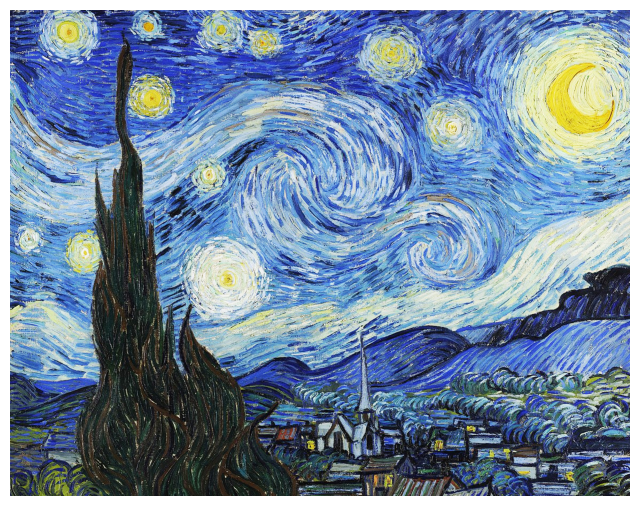

In [6]:
# the style image Starry Night by Van Gogh
plt.axis("off")
plt.imshow(keras.utils.load_img(style_reference_image_path));

We also need some auxiliary functions for loading, preprocessing, and postprocessing
the images that go in and out of the VGG19 convnet.

In [7]:
def preprocess_image(image_path):
    """Utility function to open, resize and format pictures into
    appropriate arrays.
    """
    img = keras.utils.load_img(image_path, target_size=(img_height, img_width))
    img = keras.utils.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = keras.applications.vgg19.preprocess_input(img)
    return img

def deprocess_image(img):
    """Utility function to convert a NumPy array into a valid image.
    """
    img = img.reshape((img_height, img_width, 3))
    
    # zero centering by removing the mean pixel value from ImageNet.  This
    # reverses a transformation done by vgg19.preprocess_input
    img[:, :, 0] += 103.939
    img[:, :, 1] += 116.779
    img[:, :, 2] += 123.68

    # converts images from 'BGR' to 'RGB', this is also part of the reversal
    # of vgg19.preprocess_input
    img = img[:, :, ::-1]
    
    img = np.clip(img, 0, 255).astype("uint8")
    return img

Let’s set up the VGG19 network. Like in the DeepDream example, we’ll use the pretrained
convnet to create a feature exactor model that returns the activations of intermediate
layers—all layers in the model this time.

In [8]:
model = keras.applications.vgg19.VGG19(weights="imagenet", include_top=False)

outputs_dict = dict([(layer.name, layer.output) for layer in model.layers])

feature_extractor = keras.Model(inputs=model.inputs, outputs=outputs_dict)

model.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

Let's define the content loss, which will make sure the top layer of the
VGG19 convnet has a similar view of the style image and the combination image.

In [9]:
# content loss
def content_loss(base_img, combination_img):
    return tf.reduce_sum(tf.square(combination_img - base_img))

Next is the style loss.  It uses an auxiliar function to compute the Gram matrix
of an input matrix: a map of the correlations found in the original feature matrix.

In [10]:
# style loss
def gram_matrix(x):
    x = tf.transpose(x, (2, 0, 1))
    features = tf.reshape(x, (tf.shape(x)[0], -1))
    gram = tf.matmul(features, tf.transpose(features))
    return gram

def style_loss(style_img, combination_img):
    S = gram_matrix(style_img)
    C = gram_matrix(combination_img)
    channels = 3
    size = img_height * img_width
    return tf.reduce_sum(tf.square(S - C)) / (4.0 * (channels ** 2) * (size ** 2))

To these two loss components, you add a third: the **total variation loss** which operates on
the pixels of the generated combination image.  It encourages spatial continuity in the
generated image, thus avoiding overly pixelated results.  You can interpret it as
a regularization loss (penalty for not modifying pixels or pixelating them when not needed).

In [11]:
# total variation loss
def total_variation_loss(x):
    a = tf.square(x[:, : img_height - 1, : img_width - 1, :] - x[:, 1:, : img_width - 1, :])
    b = tf.square(x[:, : img_height - 1, : img_width - 1, :] - x[:, : img_height - 1, 1:, :])
    return tf.reduce_sum(tf.pow(a + b, 1.25))

The loss that you minimize is a weighted average of these 3 losses.  

To compute the content loss, we use only one upper layer `block5_conv2`.

For the style loss, we use a list of layers that spans both low-level and high-level layers.

We add the total variation loss at the end.

Depending on the style-reference image and content image you’re using, you’ll
likely want to tune the content_weight coefficient (the contribution of the content
loss to the total loss). A higher content_weight means the target content will be more
recognizable in the generated image.

In [12]:
# defining the final lass that we will minimize

# list of layers to use for the style loss
style_layer_names = [
    "block1_conv1",
    "block2_conv1",
    "block3_conv1",
    "block4_conv1",
    "block5_conv1",
]

# The layer to use for the content loss
content_layer_name = "block5_conv2"

# contribution weight of the total variation loss
total_variation_weight = 1e-6

# contribution weight of the style loss
style_weight = 1e-6

# contribution weight of the content loss
content_weight = 2.5e-8

def compute_loss(combination_image, base_image, style_reference_image):
    """Loss function for our neural transfer example.  Uses the loaded
    VGG19 model to extract layer activations.  This is a weighted
    combination of 3 loss functions, style loss, content loss, and
    total variation loss.
    """
    input_tensor = tf.concat([base_image, style_reference_image, combination_image], axis=0)
    features = feature_extractor(input_tensor)

    # initialize loss to 0
    loss = tf.zeros(shape=())

    # add the content loss
    layer_features = features[content_layer_name]
    base_image_features = layer_features[0, :, :, :]
    combination_features = layer_features[2, :, :, :]
    loss = loss + content_weight * content_loss(base_image_features, combination_features)

    # add the style loss over all the layers selected to compute style loss for
    for layer_name in style_layer_names:
        layer_features = features[layer_name]
        style_reference_features = layer_features[1, :, :, :]
        combination_features = layer_features[2, :, :, :]
        style_loss_value = style_loss(style_reference_features, combination_features)
        loss += (style_weight / len(style_layer_names)) * style_loss_value

    # finally add the variation loss
    loss += total_variation_weight * total_variation_loss(combination_image)
    
    return loss

Finally, let’s set up the gradient-descent process.

We’ll just do mini-batch gradient descent with the SGD optimizer instead. We’ll
leverage an optimizer feature you haven’t seen before: a learning-rate schedule. We’ll
use it to gradually decrease the learning rate from a very high value (100) to a much
smaller final value (about 20). That way, we’ll make fast progress in the early stages of
training and then proceed more cautiously as we get closer to the loss minimum.

In [13]:
# setting up the gradient descent process

# we make training steps fast by compiling as a tf.function using decorator
@tf.function
def compute_loss_and_grads(combination_image, base_image, style_reference_image):
    """Compute gradient of our neural transfer loss.  We compute loss between 
    combination image and base image in gradient tape, so we can obptimize
    combination image according to calculated gradients.
    """
    with tf.GradientTape() as tape:
        loss = compute_loss(combination_image, base_image, style_reference_image)
    grads = tape.gradient(loss, combination_image)
    return loss, grads

# we'll start with a learning rate of 100 and decrase it by 4% every 100 steps
optimizer = keras.optimizers.SGD(
    keras.optimizers.schedules.ExponentialDecay(initial_learning_rate=100.0, decay_steps=100, decay_rate=0.96)
)

# preprocess the images, use a tf Variable to store the combination image
# since we will be updating it during training
base_image = preprocess_image(base_image_path)
style_reference_image = preprocess_image(style_reference_image_path)
combination_image = tf.Variable(preprocess_image(base_image_path))

# perform a gradient descent optimization loop by hand, but using the SGD optimizer
# we created to apply the calculated gradients
iterations = 4000
for i in range(1, iterations + 1):
    loss, grads = compute_loss_and_grads(combination_image, base_image, style_reference_image)

    # update the combination image in a direction that reduces the style transfer loss we defined
    optimizer.apply_gradients([(grads, combination_image)])

    # report progress and save combination image at regular intervals
    if i % 100 == 0:
        print(f"Iteration {i}: loss={loss:.2f}")
        img = deprocess_image(combination_image.numpy())
        fname = f"../figures/combination_image_at_iteration_{i}.png"
        keras.utils.save_img(fname, img)

I0000 00:00:1750789433.789560   27221 cuda_dnn.cc:529] Loaded cuDNN version 90300


Iteration 100: loss=8139.75
Iteration 200: loss=6654.43
Iteration 300: loss=6064.16
Iteration 400: loss=5742.59
Iteration 500: loss=5535.41
Iteration 600: loss=5388.59
Iteration 700: loss=5278.71
Iteration 800: loss=5193.11
Iteration 900: loss=5124.08
Iteration 1000: loss=5067.05
Iteration 1100: loss=5019.30
Iteration 1200: loss=4978.58
Iteration 1300: loss=4943.38
Iteration 1400: loss=4912.48
Iteration 1500: loss=4885.24
Iteration 1600: loss=4861.07
Iteration 1700: loss=4839.46
Iteration 1800: loss=4820.05
Iteration 1900: loss=4802.55
Iteration 2000: loss=4786.71
Iteration 2100: loss=4772.27
Iteration 2200: loss=4759.12
Iteration 2300: loss=4747.09
Iteration 2400: loss=4736.03
Iteration 2500: loss=4725.85
Iteration 2600: loss=4716.42
Iteration 2700: loss=4707.67
Iteration 2800: loss=4699.52
Iteration 2900: loss=4691.91
Iteration 3000: loss=4684.78
Iteration 3100: loss=4678.11
Iteration 3200: loss=4671.86
Iteration 3300: loss=4666.06
Iteration 3400: loss=4660.64
Iteration 3500: loss=46

The following shows an example of what you get.  Keep in mind this technique achieves merely
a form of image retexturing, or texture transfer.

![Style transfer results](../figures/combination_image_at_iteration_4000.png)

Additionally, note that this style-transfer algorithm is slow to run. But the transformation
operated by the setup is simple enough that it can be learned by a small, fast
feedforward convnet as well—as long as you have appropriate training data available.

## Summary

<font color='blue'>
    
- Style transfer consists of creating a new image that preserves the contents of a
  target image while also capturing the style of a reference image.
- Content can be captured by the high-level activations of a convnet.
- Style can be captured by the internal correlations of the activations of different
  layers of a convnet.
- Hence, deep learning allows style transfer to be formulated as an optimization
  process using a loss defined with a pretrained convnet.
- Starting from this basic idea, many variants and refinements are possible.